<a href="https://colab.research.google.com/github/AdarkarRavaji2004/CSL701-CS01_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Ravaji Parshuram Adarkar | Roll No. : CS01

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [23]:
# Task 1: Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [25]:
# Task 2: Load and inspect dataset

df = pd.read_csv('/content/cardekho_dataset.csv')

print("First 5 records:")
display(df.head())

print("\nRows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nNumerical Attributes:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Attributes:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

print("\nTarget Variable: selling_price")

First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Rows and Columns:
(15411, 14)

Column Names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical Attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical Attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target Variable: selling_price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [26]:
# Task 3: Check missing values

print("Missing values:")
print(df.isnull().sum())

# Remove rows containing missing values
df = df.dropna()

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nPreprocessing: Missing rows were removed.")

Missing values:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Missing values after handling:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Preprocessing: Missing rows were removed.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [27]:
# Task 4: Select features

features = [
    'vehicle_age',
    'km_driven',
    'seller_type',
    'fuel_type',
    'transmission_type',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

X = df[features]
y = df['selling_price']

print("Selected Features:")
print(features)

print("\nPredictor Matrix X:")
display(X.head())

print("\nTarget Variable y:")
display(y.head())

Selected Features:
['vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']

Predictor Matrix X:


,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



Target Variable y:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [28]:
# Task 5: Encode categorical variables

X = pd.get_dummies(
    X,
    columns=['seller_type', 'fuel_type', 'transmission_type'],
    drop_first=True
)

# Convert True/False to 1/0
X = X.astype(float)

print("Dataset after encoding:")
display(X.head())

print("\nAll predictors are numerical.")
print(X.dtypes)

Dataset after encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9.0,120000.0,19.70,796.0,46.30,5.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5.0,20000.0,18.90,1197.0,82.00,5.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11.0,60000.0,17.00,1197.0,80.00,5.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9.0,37000.0,20.92,998.0,67.10,5.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6.0,30000.0,22.77,1498.0,98.59,5.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



All predictors are numerical.
vehicle_age                     float64
km_driven                       float64
mileage                         float64
engine                          float64
max_power                       float64
seats                           float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
transmission_type_Manual        float64
dtype: object


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [29]:
# Task 6: Feature Engineering

print("Vehicle Age:")
print(X['vehicle_age'].head())

print("\nMinimum Vehicle Age:", X['vehicle_age'].min())
print("Maximum Vehicle Age:", X['vehicle_age'].max())

print("\nThe dataset already contains vehicle_age.")
print("Therefore, no new Car_Age column is required.")

Vehicle Age:
0     9.0
1     5.0
2    11.0
3     9.0
4     6.0
Name: vehicle_age, dtype: float64

Minimum Vehicle Age: 0.0
Maximum Vehicle Age: 29.0

The dataset already contains vehicle_age.
Therefore, no new Car_Age column is required.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

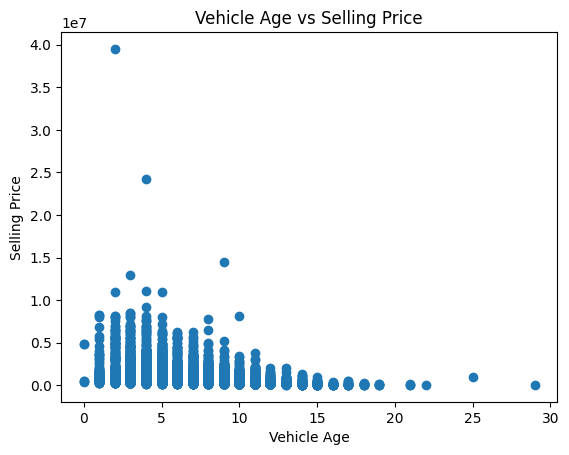

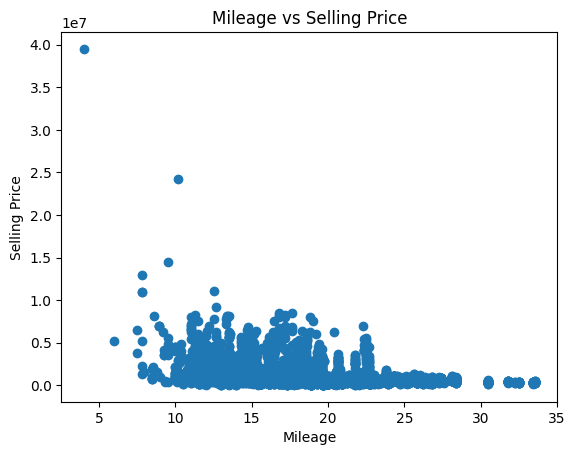

In [30]:
# Task 7: EDA

# Vehicle Age vs Selling Price
plt.scatter(X['vehicle_age'], y)

plt.xlabel('Vehicle Age')
plt.ylabel('Selling Price')
plt.title('Vehicle Age vs Selling Price')

plt.show()


# Mileage vs Selling Price
plt.scatter(X['mileage'], y)

plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.title('Mileage vs Selling Price')

plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [31]:
# Task 8: Standardize numerical features

# Convert X and y to NumPy arrays
X_array = X.values
y_array = y.values

# Random split
np.random.seed(42)

indices = np.random.permutation(len(X_array))

train_size = int(0.8 * len(X_array))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

Xtrain = X_array[train_indices]
Xtest = X_array[test_indices]

ytrain = y_array[train_indices]
ytest = y_array[test_indices]

# Numerical columns
numerical_columns = [0, 1, 5, 6, 7, 8]

# Mean and standard deviation from training data
mean = Xtrain[:, numerical_columns].mean(axis=0)
std = Xtrain[:, numerical_columns].std(axis=0)

# Standardize training data
Xtrain[:, numerical_columns] = (
    Xtrain[:, numerical_columns] - mean
) / std

# Standardize test data using training values
Xtest[:, numerical_columns] = (
    Xtest[:, numerical_columns] - mean
) / std

print("Numerical features standardized successfully.")
print("Selling price was not standardized.")

Numerical features standardized successfully.
Selling price was not standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [32]:
# Task 9: Check train-test split

print("Total observations:", len(X_array))

print("Training observations:", len(Xtrain))
print("Testing observations:", len(Xtest))

print("\nTraining percentage:",
      len(Xtrain) / len(X_array) * 100)

print("Testing percentage:",
      len(Xtest) / len(X_array) * 100)

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Training percentage: 79.99480890273182
Testing percentage: 20.005191097268185


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [33]:
# Task 10: Construct matrices

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

print("\nNumber of predictor columns:", Xtrain.shape[1])

Xtrain shape: (12328, 13)
ytrain shape: (12328,)
Xtest shape: (3083, 13)
ytest shape: (3083,)

Number of predictor columns: 13


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [34]:
# Task 11: Add bias column

# Create column of ones
ones_train = np.ones((Xtrain.shape[0], 1))
ones_test = np.ones((Xtest.shape[0], 1))

# Add bias column
Xtrain = np.hstack((ones_train, Xtrain))
Xtest = np.hstack((ones_test, Xtest))

print("Xtrain shape:", Xtrain.shape)
print("Xtest shape:", Xtest.shape)

print("\nFirst 5 rows:")
print(Xtrain[:5])

print("\nFirst column represents the intercept.")

Xtrain shape: (12328, 14)
Xtest shape: (3083, 14)

First 5 rows:
[[ 1.00000000e+00  1.97683120e+00  3.17732278e-01  2.03600000e+01
   1.19700000e+03  7.89000000e+01 -4.02990451e-01 -7.70848005e-01
  -1.03235095e-01 -9.65707676e-01  0.00000000e+00  0.00000000e+00
   1.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -6.73274828e-01  4.23561590e-02  2.73900000e+01
   1.24800000e+03  7.40000000e+01 -4.02990451e-01  1.29727261e+00
  -1.03235095e-01  1.03551005e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00  3.20514932e-01  7.39975660e-01  2.07700000e+01
   1.24800000e+03  8.87600000e+01  2.06745524e+00 -7.70848005e-01
  -1.03235095e-01  1.03551005e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -1.66706459e+00 -9.39818665e-01  1.84000000e+01
   1.49800000e+03  1.19350000e+02 -4.02990451e-01 -7.70848005e-01
  -1.03235095e-01 -9.65707676e-01  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [35]:
# Task 12: OLS function

def OLS(X, y):

    XT = X.T

    XTX = XT @ X

    XTy = XT @ y

    beta = np.linalg.inv(XTX) @ XTy

    return beta


print("OLS function created successfully.")

OLS function created successfully.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [36]:
# Task 13: Check matrix singularity

XTX = Xtrain.T @ Xtrain

determinant = np.linalg.det(XTX)

print("Determinant of X'X:")
print(determinant)

if abs(determinant) < 1e-10:
    print("\nMatrix is singular or nearly singular.")
else:
    print("\nMatrix is not singular.")
    print("OLS can be applied.")

Determinant of X'X:
5.651310583388851e+56

Matrix is not singular.
OLS can be applied.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [37]:
# Task 14: Train model

beta = OLS(Xtrain, ytrain)

print("Regression Coefficients:\n")

print("Intercept (Beta 0):", beta[0])

for i in range(1, len(beta)):
    print("Beta", i, "=", beta[i])

Regression Coefficients:

Intercept (Beta 0): -1016585.4934085794
Beta 1 = -195163.09053546618
Beta 2 = -34965.026012037044
Beta 3 = 14953.937954661902
Beta 4 = 92.65685022444791
Beta 5 = 15074.260334502706
Beta 6 = 6812.174316661636
Beta 7 = -3280.0579079398303
Beta 8 = -7967.6977187023585
Beta 9 = -62308.27770061605
Beta 10 = -96756.41053169966
Beta 11 = 358735.63796483725
Beta 12 = -119859.21560935304
Beta 13 = -121450.2303761486


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [38]:
# Task 15: Interpret coefficients

feature_names = X.columns.tolist()

print("Regression Coefficient Interpretation\n")

print("Intercept:", beta[0])
print()

for feature, coefficient in zip(feature_names, beta[1:]):

    print("Feature:", feature)
    print("Coefficient:", round(coefficient, 4))

    if coefficient > 0:
        print("Effect: Positive")
        print("Meaning: Increase in this feature tends to increase selling price.")

    elif coefficient < 0:
        print("Effect: Negative")
        print("Meaning: Increase in this feature tends to decrease selling price.")

    else:
        print("Effect: Zero")

    print("-" * 50)

Regression Coefficient Interpretation

Intercept: -1016585.4934085794

Feature: vehicle_age
Coefficient: -195163.0905
Effect: Negative
Meaning: Increase in this feature tends to decrease selling price.
--------------------------------------------------
Feature: km_driven
Coefficient: -34965.026
Effect: Negative
Meaning: Increase in this feature tends to decrease selling price.
--------------------------------------------------
Feature: mileage
Coefficient: 14953.938
Effect: Positive
Meaning: Increase in this feature tends to increase selling price.
--------------------------------------------------
Feature: engine
Coefficient: 92.6569
Effect: Positive
Meaning: Increase in this feature tends to increase selling price.
--------------------------------------------------
Feature: max_power
Coefficient: 15074.2603
Effect: Positive
Meaning: Increase in this feature tends to increase selling price.
--------------------------------------------------
Feature: seats
Coefficient: 6812.1743
Effect

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [39]:
# Task 16: Predict selling prices

y_pred = Xtest @ beta

print("Actual vs Predicted Selling Price\n")

for i in range(10):
    print(
        "Actual:",
        round(ytest[i], 2),
        "Predicted:",
        round(y_pred[i], 2)
    )

Actual vs Predicted Selling Price

Actual: 4450000 Predicted: 2046440.49
Actual: 1290000 Predicted: 1431417.81
Actual: 485000 Predicted: 339097.18
Actual: 400000 Predicted: 543268.2
Actual: 800000 Predicted: 862352.98
Actual: 150000 Predicted: -616511.22
Actual: 650000 Predicted: 820935.0
Actual: 325000 Predicted: -175814.55
Actual: 300000 Predicted: 378640.92
Actual: 925000 Predicted: 776919.73


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [40]:
# Task 17: Calculate residuals and RSS

error = ytest - y_pred

RSS = np.sum(error ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nFirst 10 residuals:")
print(error[:10])

print("\nLower RSS means lower total prediction error.")

Residual Sum of Squares (RSS):
885105657669992.0

First 10 residuals:
[2403559.5140337  -141417.81281603  145902.81901465 -143268.19891459
  -62352.98172054  766511.22160146 -170934.99714313  500814.5513059
  -78640.91740417  148080.2689304 ]

Lower RSS means lower total prediction error.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [41]:
# Task 18: Calculate R-squared

TSS = np.sum((ytest - np.mean(ytest)) ** 2)

R2 = 1 - (RSS / TSS)

print("TSS:", TSS)
print("RSS:", RSS)
print("R²:", R2)

print("\nR² Percentage:", R2 * 100, "%")

TSS: 2407385049859876.5
RSS: 885105657669992.0
R²: 0.6323373123375049

R² Percentage: 63.23373123375049 %


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


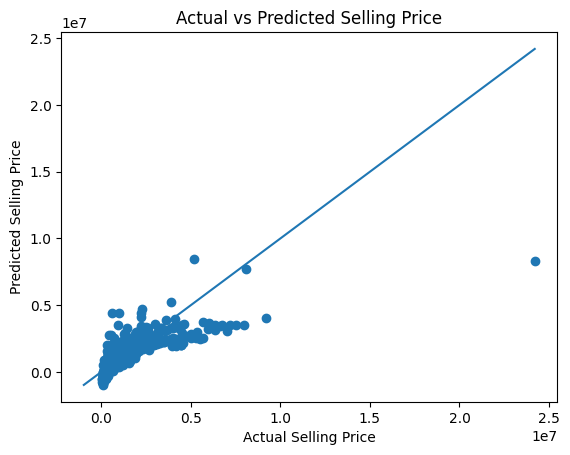

In [42]:
# Task 19: Actual vs Predicted

plt.scatter(ytest, y_pred)

minimum = min(ytest.min(), y_pred.min())
maximum = max(ytest.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')

plt.show()

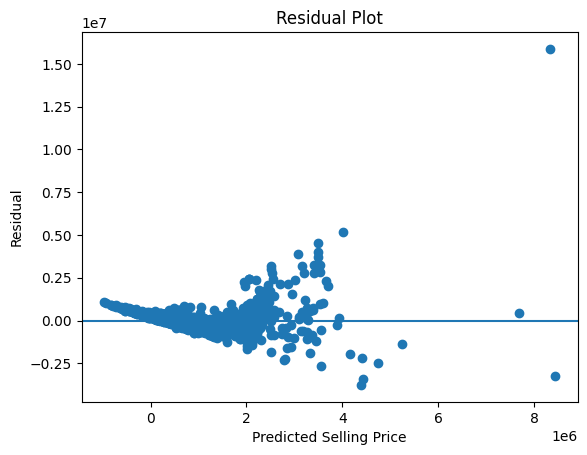

In [43]:
# Task 19: Residual Plot

plt.scatter(y_pred, error)

plt.axhline(0)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

In [44]:
# Task 19: Find large errors

absolute_error = np.abs(error)

large_errors = np.argsort(absolute_error)[-10:]

print("10 Largest Prediction Errors:\n")

for i in large_errors:
    print(
        "Actual =", round(ytest[i], 2),
        "Predicted =", round(y_pred[i], 2),
        "Error =", round(error[i], 2)
    )

10 Largest Prediction Errors:

Actual = 6645000 Predicted = 3412467.57 Error = 3232532.43
Actual = 5200000 Predicted = 8434192.83 Error = -3234192.83
Actual = 999000 Predicted = 4439604.79 Error = -3440604.79
Actual = 7199000 Predicted = 3488916.56 Error = 3710083.44
Actual = 625000 Predicted = 4390873.61 Error = -3765873.61
Actual = 7000000 Predicted = 3084722.09 Error = 3915277.91
Actual = 7500000 Predicted = 3485713.74 Error = 4014286.26
Actual = 8000000 Predicted = 3488916.56 Error = 4511083.44
Actual = 9200000 Predicted = 4009019.39 Error = 5190980.61
Actual = 24200000 Predicted = 8323205.42 Error = 15876794.58


### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.